In [1]:
import sklearn
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import proteinmlutils.featurizer as protfeat

In [2]:
protein_df=pd.read_csv("../data/A0A2Z5U3Z0_9INFA_Doud_2016.csv").sample(n=1000, random_state=42)
protein_df.rename(columns={"mutated_sequence": "protein_sequence"}, inplace=True)
protein_df

,mutant,protein_sequence,DMS_score,DMS_score_bin
10308,V544G,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.613682,0
6705,E354I,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.864511,0
304,D18T,MKAKLLVLLYAFVATDATTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.774094,0
9142,F483V,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.423986,0
10592,L559I,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-2.298089,0
...,...,...,...,...
3006,F160P,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-3.649694,0
1584,D85K,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-3.870769,0
9363,S494D,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-1.837786,1
10355,G547Y,MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,-3.386411,0


In [3]:
#check if the protein_sequence column has unique values
assert len(protein_df['protein_sequence'].unique()) == len(protein_df), "The 'protein_sequence' column does not have unique values"


In [4]:
protein_df['protein_sequence'].str.len().describe() # Check the maximum length of the protein sequences

count    1000.0
mean      565.0
std         0.0
min       565.0
25%       565.0
50%       565.0
75%       565.0
max       565.0
Name: protein_sequence, dtype: float64

In [5]:
max_length = int(protein_df['protein_sequence'].str.len().max())  # Get the maximum length of the sequences
sequence_arr = protein_df['protein_sequence'].tolist()
y_arr = protein_df['DMS_score'].tolist()


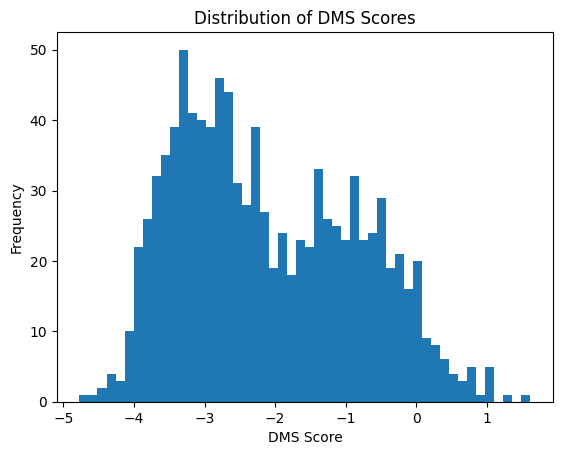

In [6]:
plt.hist(protein_df['DMS_score'], bins=50)
plt.xlabel('DMS Score')
plt.ylabel('Frequency')
plt.title('Distribution of DMS Scores')
plt.show()

In [7]:

X_arr=protfeat.protein_one_hot_encoder(sequence_arr, max_length=max_length, flatten=True)
print(X_arr.shape)  # Check the shape of the one-hot encoded array

(1000, 11865)


In [8]:
assert X_arr.shape == (len(protein_df), max_length * 21), "The shape of the one-hot encoded array does not match the expected shape"

In [9]:
embedding_dim = 5  # Set the embedding dimension
embedding_arr, embedding_weight=protfeat.protein_embedding_generator(sequence_arr, max_length, embedding_dim=embedding_dim, flatten=True)

In [10]:
assert embedding_arr.shape == (len(protein_df), max_length * embedding_dim), "The shape of the one-hot encoded array does not match the expected shape"

In [12]:
y_discretize_arr=np.digitize(y_arr,bins=[-1])

(array([763.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 237.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

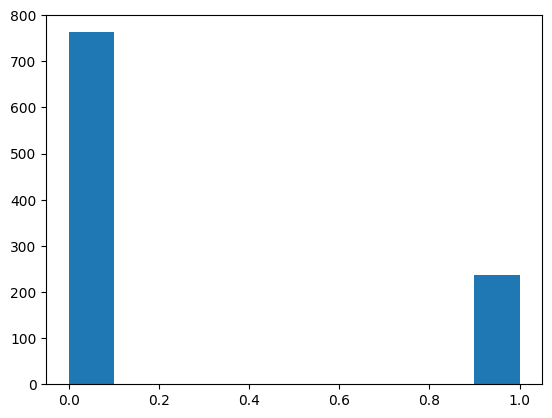

In [13]:
plt.hist(y_discretize_arr)

In [14]:
X_train, X_test, y_train, y_test=data_train_vs_test_splitting(embedding_arr,y_discretize_arr)

Training+validation sample size: 800
Test sample size: 200


In [15]:
from scipy import stats
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

kfold=3
cv_splitter=data_cross_validation_stratification(X_train, y_train, strategy='random', kfold=kfold)


In [ ]:
from sklearn.ensemble import RandomForestClassifier


def RandomForestClassifierModel_trainer(strategy='random', kfold=3, **kwargs):
        '''
        Returns a Random Forest Classifier model with default parameters.
        '''
        classifier_model = RandomForestClassifier()

        if kwargs.get('cv_splitter') is not None:
                cv_splitter = kwargs['cv_splitter']
        else:
                cv_splitter = data_cross_validation_stratification(X_train, y_train, strategy=strategy, kfold=kfold)

        if kwargs.get('param_dict') is not None:
                param_dict = kwargs['param_dict']
        else:
                param_dict  = {'n_estimators': [200,500,1000],
        'min_samples_leaf': [50,100],
        'max_depth': [10,20],
        'max_features': ["sqrt"],
        'n_jobs':[-1], 'random_state':[0]}

        scoring=["f1", "precision", "recall", "accuracy"]
        n_iter=2
        primary_scoring = 'f1'  # Define the primary scoring metric for refitting the model
        random_search = sk.model_selection.RandomizedSearchCV(classifier_model, param_dict, cv=cv_splitter, n_iter=n_iter, scoring=scoring, refit=primary_scoring, n_jobs=1, verbose=2, return_train_score=False)
        random_search.fit(X_train,y_train)
        grid_search_results_df=pd.DataFrame(random_search.cv_results_)
        best_model_found=random_search.best_estimator_
        y_pred_train=best_model_found.predict(X_train)
        y_pred=best_model_found.predict(X_test)

        #bunch of print statements to see the performance of the model on training and test model
        print("Score on training: Recall=", sk.metrics.recall_score(y_train,y_pred_train), "Precision=", sk.metrics.precision_score(y_train,y_pred_train), "F1 score=",sk.metrics.f1_score(y_train, y_pred_train))
        print("Score on test: Recall=", sk.metrics.recall_score(y_test,y_pred), "Precision=", sk.metrics.precision_score(y_test,y_pred), "F1 score=",sk.metrics.f1_score(y_test, y_pred))




IndentationError: expected an indented block after 'if' statement on line 10 (615727949.py, line 11)

In [ ]:
best_model_found

,n_estimators,500
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,100
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
grid_search_results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_random_state,param_n_jobs,param_n_estimators,param_min_samples_leaf,param_max_features,param_max_depth,...,split2_test_recall,mean_test_recall,std_test_recall,rank_test_recall,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy
0,0.309238,0.007274,0.028990,0.000996,0,-1,500,100,sqrt,20,...,0.0,0.0,0.0,1,0.756554,0.752809,0.759398,0.756254,0.002699,1
1,0.122942,0.005934,0.015991,0.000360,0,-1,200,50,sqrt,10,...,0.0,0.0,0.0,1,0.756554,0.752809,0.759398,0.756254,0.002699,1
